This notebook is a continuation of `10_classifier.ipynb`. We built some basic classification models using tree-based classifiers in that notebook. In this notebook, we will optimize the hyper-parameters of those models to try to improve their performance. The dataset used for this exercise is borrowed from [UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/datasets/default+of+credit+card+clients).

### Import packages

In [2]:
# data processing
import pandas as pd
import numpy as np

# plotting
import matplotlib.pyplot as plt
import seaborn as sns

# modeling
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# grid search
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

### Set-up

In [3]:
# input file location and name
infile = 'https://raw.githubusercontent.com/vishal-git/dapt-631/main/data/credit_default_model_data.csv'

# target variable (column name)
target = 'default payment next month'

sns.set(style='darkgrid')

### Read data

In [4]:
df = pd.read_csv(infile)

df.shape

(30000, 57)

In [5]:
df.head()

,LIMIT_BAL,AGE,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,...,pay_bucket_-2_flag,pay_bucket_-1_flag,pay_amt_total,bill_amt_total,pay_to_billed_ratio,zero_bill_amount,utilization_avg,utilization_max,group,default payment next month
0,40000,28,10371,11895,11228,2475,5341,6255,2567,0,...,0,1,11883,47565,0.249827,0,0.198187,0.297375,M,1
1,320000,35,12233,16490,20011,17918,18627,19167,7000,4100,...,0,0,15100,104446,0.144572,0,0.054399,0.062534,M,0
2,260000,35,188,188,188,188,194,188,188,188,...,0,1,1167,1134,1.029101,0,0.000727,0.000746,M,0
3,360000,36,308711,305594,306176,304645,315118,315782,11000,13000,...,0,0,71322,1856026,0.038427,0,0.859271,0.877172,M,0
4,500000,25,-46,9412,1260,0,1121,6566,9458,1260,...,0,1,20839,18313,1.137935,0,0.006104,0.018824,M,0


### Set-up X and y

In [6]:
y = df[target]
X = df.drop(target, axis=1)

X_train = X[X['group'] == 'M'].drop('group', axis=1)
X_test = X[X['group'] == 'T'].drop('group', axis=1)
X_valid = X[X['group'] == 'V'].drop('group', axis=1)

y_train = y[X['group'] == 'M']
y_test = y[X['group'] == 'T']
y_valid = y[X['group'] == 'V']

print(len(X_train), len(X_test), len(X_valid))

del df


def get_scores(model_dict, X):
    scores = {}
    for key, model in model_dict.items():
        scores[key] = model.predict_proba(X)[:, 1]
    return scores


def get_roc_info(y_true, score_dict):
    roc_info = {}
    for key, scores in score_dict.items():
        fpr, tpr, _ = roc_curve(y_true, scores)
        auc = roc_auc_score(y_true, scores)
        roc_info[key] = {'fpr': fpr, 'tpr': tpr, 'auc': auc}
    return roc_info


def plot_train_test_roc(roc_train, roc_test, key, color, model_label, title):
    plt.figure(figsize=(12, 9))

    plt.plot(
        roc_train[key]['fpr'],
        roc_train[key]['tpr'],
        color=color,
        lw=2,
        alpha=0.4,
        label=f'{model_label} Train (AUC = {roc_train[key]["auc"]:0.3f})'
    )

    plt.plot(
        roc_test[key]['fpr'],
        roc_test[key]['tpr'],
        color=color,
        lw=2,
        label=f'{model_label} Test (AUC = {roc_test[key]["auc"]:0.3f})'
    )

    plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.0])
    plt.xlabel('False Positive Rate', fontsize=14)
    plt.ylabel('True Positive Rate', fontsize=14)
    plt.title(title, fontsize=16)
    plt.legend(loc='lower right', fontsize=14);

15000 7500 7500


### Decision Tree

We will now fine-tune hyper-parameters for a decision (classification) tree.

#### Max Depth

In [7]:
# create a list of all values we would like to test
max_depths = np.linspace(1, 20, 20)

max_depths

array([ 1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12., 13.,
       14., 15., 16., 17., 18., 19., 20.])

We will build a decision tree model using each value of `max_depth`. Once all models are built, we will pick the best value for `max_depth` based on model performance on the test set.

In [8]:
# create empty arrays -- we will use these to store model performance values
auc_train, auc_test = [], []

for d in max_depths:
    
    # define the model
    tree = DecisionTreeClassifier(max_depth=int(d), random_state=314)
    
    # fit the model
    tree.fit(X_train, y_train)
    
    # get model scores
    scores_train = tree.predict_proba(X_train)[:, 1]
    scores_test = tree.predict_proba(X_test)[:, 1]
    
    # save the AUC values
    auc_train.append(roc_auc_score(y_train, scores_train))
    auc_test.append(roc_auc_score(y_test, scores_test))

Let's plot model performance.

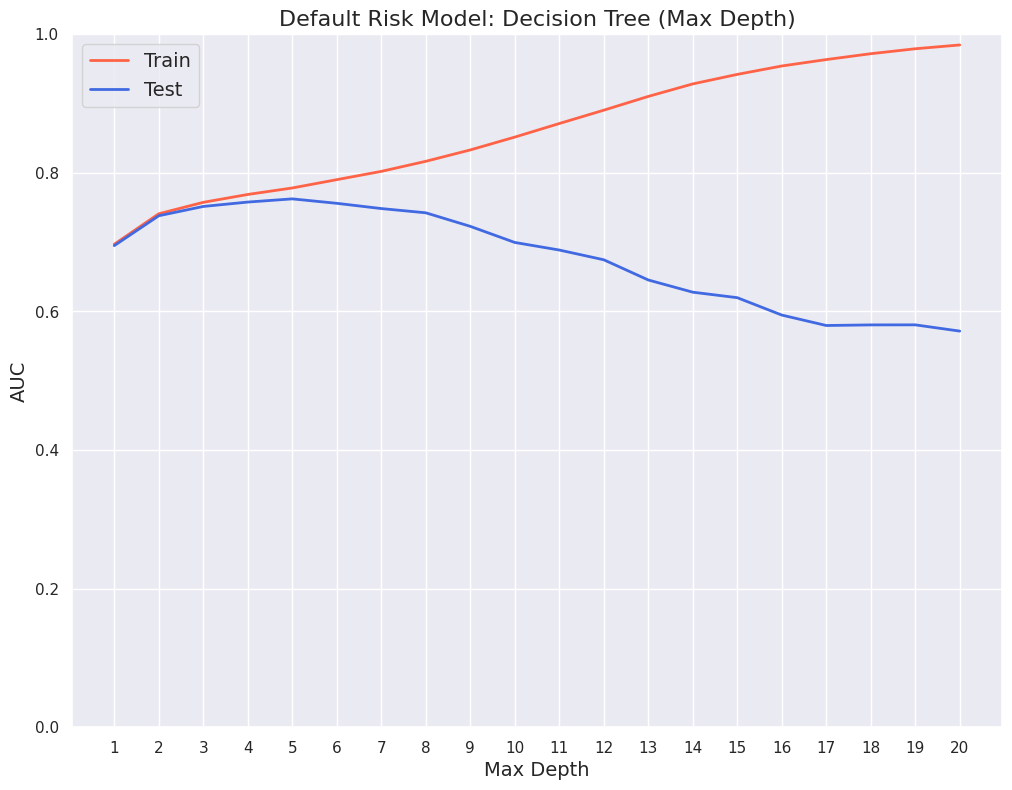

In [9]:
plt.figure(figsize=(12, 9))

plt.plot(max_depths, auc_train, color='tomato', lw=2, label='Train')

plt.plot(max_depths, auc_test, color='royalblue', lw=2, label='Test')

plt.xticks(max_depths)
plt.ylim([0.0, 1.0])

plt.xlabel('Max Depth', fontsize=14)
plt.ylabel('AUC', fontsize=14)
plt.title('Default Risk Model: Decision Tree (Max Depth)', fontsize=16)
plt.legend(loc='best', fontsize=14);

Find where AUC on the test set is highest.

In [10]:
best_loc = [i for i, auc_test_value in enumerate(auc_test) if auc_test_value == max(auc_test)]
best_loc

[4]

In [11]:
auc_test

[0.6949693034451732,
 0.7380894350159106,
 0.7515132256258353,
 0.7578341790826665,
 0.7624471286940131,
 0.756037457760424,
 0.7484754858577468,
 0.7423484383261142,
 0.7228086834552219,
 0.6995709132286634,
 0.6886262347584504,
 0.6745849109890218,
 0.645418360628282,
 0.6278074540331612,
 0.6198743978089605,
 0.594809222020078,
 0.5797201699927426,
 0.5805923105089109,
 0.5806586048871476,
 0.5716505740313222]

In [12]:
best_auc = auc_test[best_loc[0]]
best_auc

0.7624471286940131

In [13]:
best_max_depth = max_depths[best_loc[0]]
best_max_depth

np.float64(5.0)

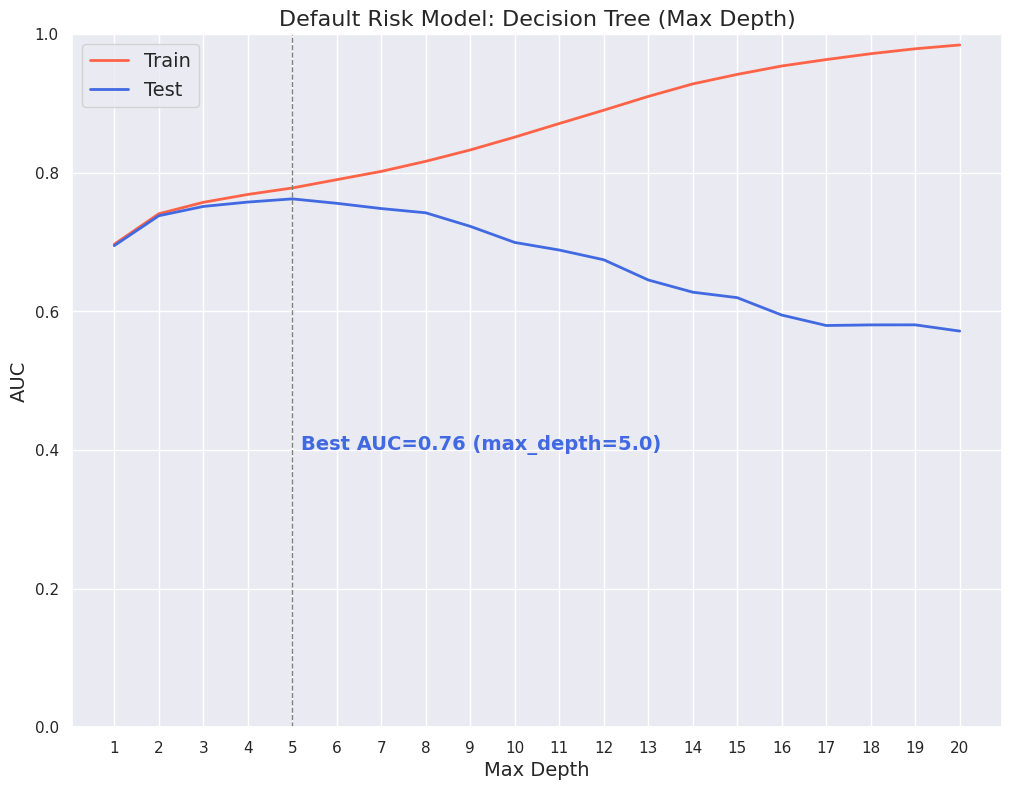

In [14]:
plt.figure(figsize=(12, 9))

plt.plot(max_depths, auc_train, color='tomato', lw=2, label='Train')

plt.plot(max_depths, auc_test, color='royalblue', lw=2, label='Test')

plt.plot([5, 5], [0, 1], color='gray', linewidth=1, linestyle='--')
plt.text(5+.2, 0.4, f'Best AUC={best_auc:.2f} (max_depth={best_max_depth})', fontsize=14,
         color='royalblue', weight='semibold')

plt.xticks(max_depths)
plt.ylim([0.0, 1.0])

plt.xlabel('Max Depth', fontsize=14)
plt.ylabel('AUC', fontsize=14)
plt.title('Default Risk Model: Decision Tree (Max Depth)', fontsize=16)
plt.legend(loc='best', fontsize=14);

#### Minimum Samples in Leaf Nodes

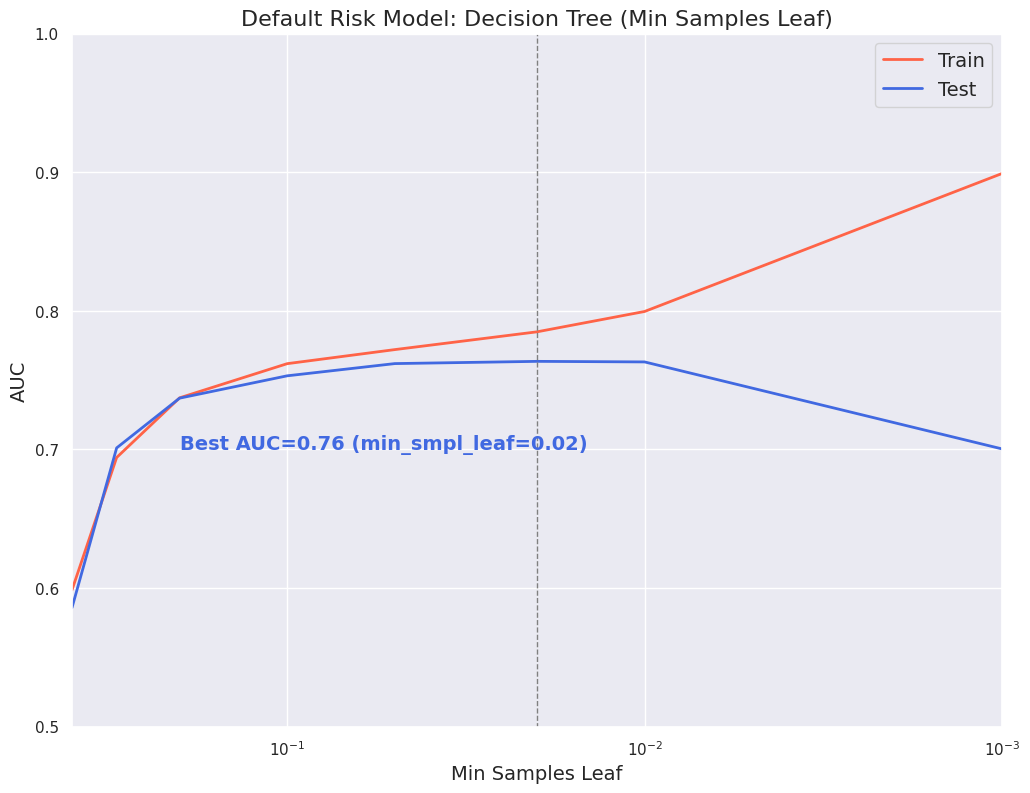

In [15]:
# create a list of all values we would like to test
min_smpl_leaf = [0.4, 0.3, 0.2, 0.1, 0.05, 0.02, 0.01, 0.001]

# create empty arrays -- we will use these to store model performance values
auc_train, auc_test = [], []

for msl in min_smpl_leaf:
    
    # define the model
    tree = DecisionTreeClassifier(min_samples_leaf=msl, random_state=314)
    
    # fit the model
    tree.fit(X_train, y_train)
    
    # get model scores
    scores_train = tree.predict_proba(X_train)[:, 1]
    scores_test = tree.predict_proba(X_test)[:, 1]
    
    # save the AUC values
    auc_train.append(roc_auc_score(y_train, scores_train))
    auc_test.append(roc_auc_score(y_test, scores_test))
  
# identify the best value for min_samples_leaf
best_loc = [i for i, auc_test_value in enumerate(auc_test) if auc_test_value == max(auc_test)][0]
best_auc = auc_test[best_loc]
best_msl = min_smpl_leaf[best_loc]

# plot the model performances
plt.figure(figsize=(12, 9))

plt.plot(min_smpl_leaf, auc_train, color='tomato', lw=2, label='Train')

plt.plot(min_smpl_leaf, auc_test, color='royalblue', lw=2, label='Test')

plt.plot([best_msl, best_msl], [0, 1], color='gray', linewidth=1, linestyle='--')
plt.text(0.2, 0.7, f'Best AUC={best_auc:.2f} (min_smpl_leaf={best_msl})', fontsize=14,
         color='royalblue', weight='semibold')

plt.xticks(min_smpl_leaf)
plt.xlim([max(min_smpl_leaf), min(min_smpl_leaf)])
plt.xscale('log')
plt.ylim([0.5, 1.0])

plt.xlabel('Min Samples Leaf', fontsize=14)
plt.ylabel('AUC', fontsize=14)
plt.title('Default Risk Model: Decision Tree (Min Samples Leaf)', fontsize=16)
plt.legend(loc='best', fontsize=14);

#### Grid-search

Instead of tuning one hyper-parameter at a time, we can use grid search to assess combinations of hyper-parameters.

In [16]:
tree = DecisionTreeClassifier(random_state=314)

# create a list of all parameters we want to test
param_grid = {'max_depth': [4, 5, 6], 'min_samples_leaf': [0.05, 0.03, 0.02]}

# define the gridsearch object
tree_gs = GridSearchCV(tree, param_grid, cv=3, verbose=2, n_jobs=-1)

# fit the model
tree_gs.fit(X_train, y_train)

Fitting 3 folds for each of 9 candidates, totalling 27 fits


[CV] END .................max_depth=4, min_samples_leaf=0.05; total time=   0.1s
[CV] END .................max_depth=4, min_samples_leaf=0.05; total time=   0.1s
[CV] END .................max_depth=4, min_samples_leaf=0.05; total time=   0.1s
[CV] END .................max_depth=4, min_samples_leaf=0.03; total time=   0.1s
[CV] END .................max_depth=4, min_samples_leaf=0.03; total time=   0.1s
[CV] END .................max_depth=4, min_samples_leaf=0.03; total time=   0.1s
[CV] END .................max_depth=4, min_samples_leaf=0.02; total time=   0.1s
[CV] END .................max_depth=4, min_samples_leaf=0.02; total time=   0.1s
[CV] END .................max_depth=4, min_samples_leaf=0.02; total time=   0.1s
[CV] END .................max_depth=5, min_samples_leaf=0.05; total time=   0.1s
[CV] END .................max_depth=5, min_samples_leaf=0.05; total time=   0.1s
[CV] END .................max_depth=5, min_samples_leaf=0.03; total time=   0.1s
[CV] END .................ma

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...dom_state=314)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [4, 5, ...], 'min_samples_leaf': [0.05, 0.03, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed

Find the best set of hyper-parameters.

In [17]:
tree_gs.best_params_

{'max_depth': 4, 'min_samples_leaf': 0.02}

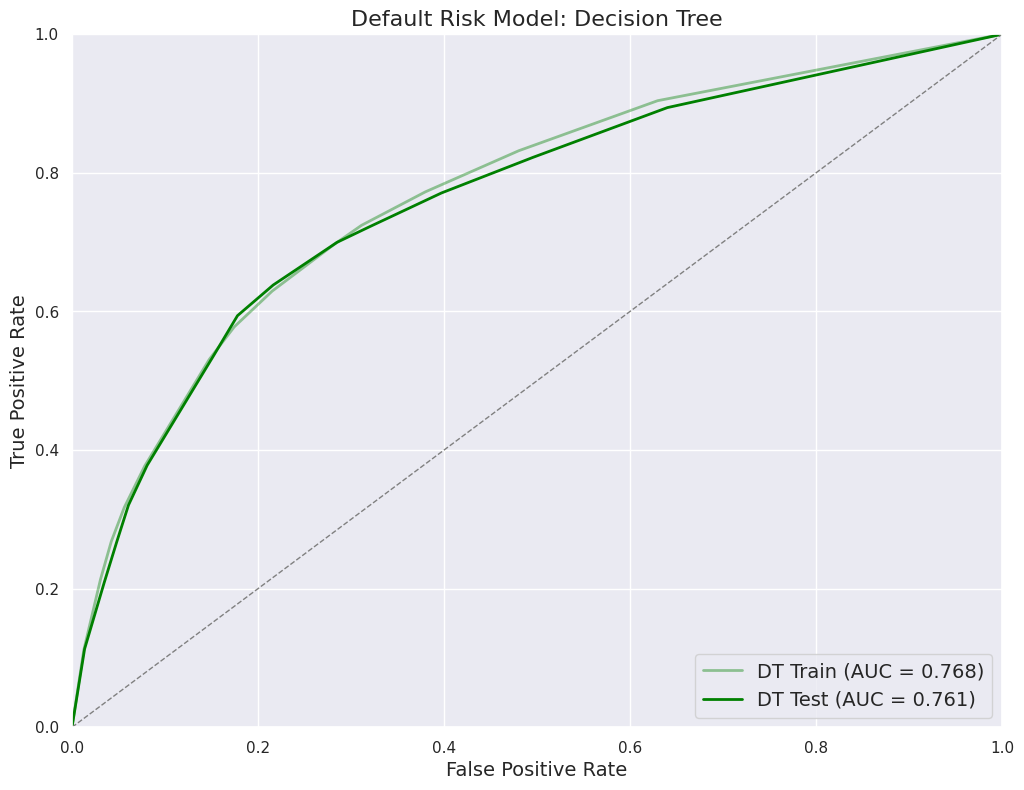

In [18]:
tree_scores_train = get_scores({'DT': tree_gs}, X_train)
tree_scores_test = get_scores({'DT': tree_gs}, X_test)

tree_roc_train = get_roc_info(y_train, tree_scores_train)
tree_roc_test = get_roc_info(y_test, tree_scores_test)

plot_train_test_roc(
    tree_roc_train,
    tree_roc_test,
    key='DT',
    color='green',
    model_label='DT',
    title='Default Risk Model: Decision Tree'
)

### Random Forest

Instead of testing every combination of hyper-parameters, we can use random search, which samples random combinations from the given set.

We will use random search to optimize the following hyper-parameters for a Random Forest model.

Number of trees in the random forest: `n_estimators = [200, 300]`

Maximum tree depth: `max_depth = [3, 6]`

Minimum percentage of samples required in leaf nodes: `min_samples_leaf = [0.02, 0.05]`

Whether to sample with replacement for each tree: `bootstrap = [True, False]`

In [19]:
forest = RandomForestClassifier(random_state=314)

param_grid = {'n_estimators': [200, 300], 
              'max_depth': [3, 6],
              'min_samples_leaf': [0.02, 0.05],
              'bootstrap': [True, False]}

forest_gs = RandomizedSearchCV(forest, param_grid, cv=3, verbose=2, n_iter=10,
                               n_jobs=-1, random_state=314)

forest_gs.fit(X_train, y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
[CV] END bootstrap=True, max_depth=3, min_samples_leaf=0.05, n_estimators=200; total time=   1.0s
[CV] END bootstrap=True, max_depth=3, min_samples_leaf=0.05, n_estimators=200; total time=   1.0s
[CV] END bootstrap=True, max_depth=3, min_samples_leaf=0.05, n_estimators=200; total time=   1.1s
[CV] END bootstrap=True, max_depth=6, min_samples_leaf=0.02, n_estimators=200; total time=   1.5s
[CV] END bootstrap=True, max_depth=3, min_samples_leaf=0.02, n_estimators=200; total time=   1.0s
[CV] END bootstrap=True, max_depth=6, min_samples_leaf=0.02, n_estimators=200; total time=   1.5s
[CV] END bootstrap=True, max_depth=6, min_samples_leaf=0.02, n_estimators=200; total time=   1.5s
[CV] END bootstrap=True, max_depth=3, min_samples_leaf=0.02, n_estimators=200; total time=   1.1s
[CV] END bootstrap=True, max_depth=3, min_samples_leaf=0.02, n_estimators=200; total time=   1.1s
[CV] END bootstrap=False, max_depth=3, min_samples_leaf=0

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...dom_state=314)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'bootstrap': [True, False], 'max_depth': [3, 6], 'min_samples_leaf': [0.02, 0.05], 'n_estimators': [200, 300]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 

In [20]:
forest_gs.best_params_

{'n_estimators': 200,
 'min_samples_leaf': 0.02,
 'max_depth': 6,
 'bootstrap': False}

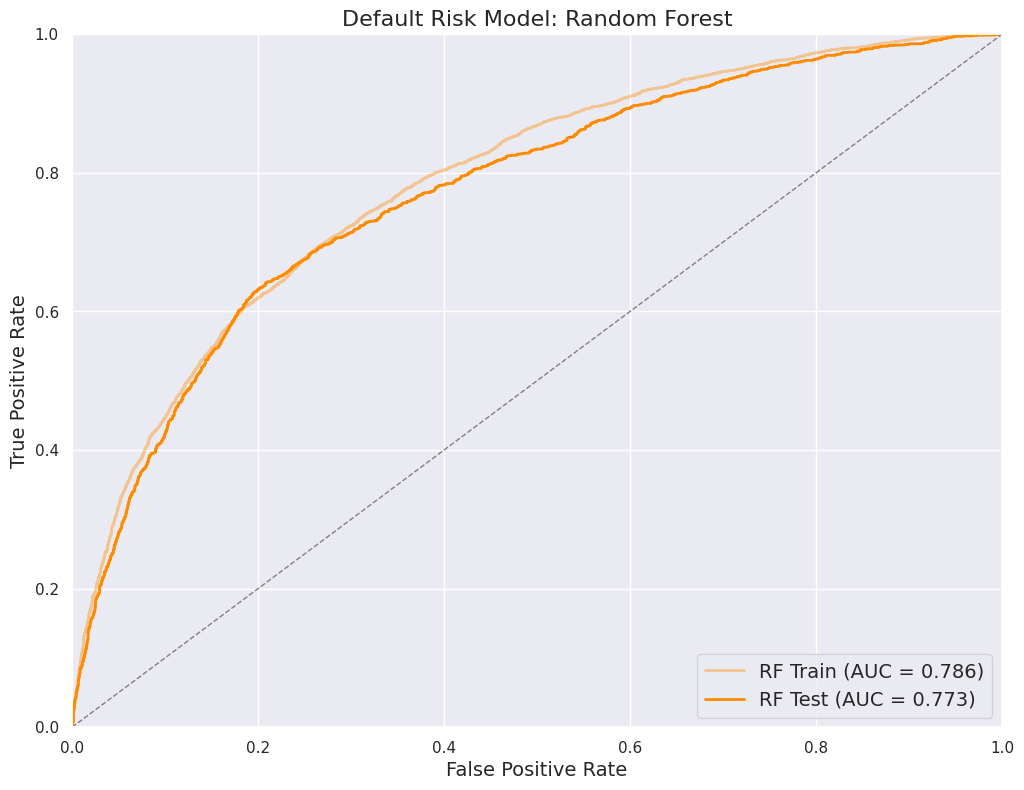

In [21]:
forest_scores_train = get_scores({'RF': forest_gs}, X_train)
forest_scores_test = get_scores({'RF': forest_gs}, X_test)

forest_roc_train = get_roc_info(y_train, forest_scores_train)
forest_roc_test = get_roc_info(y_test, forest_scores_test)

plot_train_test_roc(
    forest_roc_train,
    forest_roc_test,
    key='RF',
    color='darkorange',
    model_label='RF',
    title='Default Risk Model: Random Forest'
)

Note: Once you find the best set of hyper-parameters, you can refine them further by running another random search with a new parameter range. The new values can be chosen based on the results of the first random search.

Next, we will perform random search to optimize the following hyper-parameters for a *Gradient Boosting* model.

Number of trees: `n_estimators = [100, 300, 500]`

Learning rate: `learning_rate = [0.05, 0.1]`

Maximum tree depth: `max_depth = [3, 6]`

Minimum percentage of samples required in leaf nodes: `min_samples_leaf = [0.01, 0.02, 0.05]`


In [22]:
gbm = GradientBoostingClassifier(random_state=314)

param_grid = {'n_estimators': [100, 300, 500], 
              'learning_rate': [0.05, 0.1],
              'max_depth': [3, 6],
              'min_samples_leaf': [0.01, 0.02, 0.05]}

gbm_rs = RandomizedSearchCV(gbm, param_grid, cv=3, n_iter=10, n_jobs=-1, random_state=314)

gbm_rs.fit(X_train, y_train)

print('Best GBM Parameters:', gbm_rs.best_params_)

gbm_scores_train = get_scores({'GBM': gbm_rs}, X_train)
gbm_scores_test = get_scores({'GBM': gbm_rs}, X_test)

gbm_roc_train = get_roc_info(y_train, gbm_scores_train)
gbm_roc_test = get_roc_info(y_test, gbm_scores_test)

Best GBM Parameters: {'n_estimators': 300, 'min_samples_leaf': 0.01, 'max_depth': 3, 'learning_rate': 0.05}


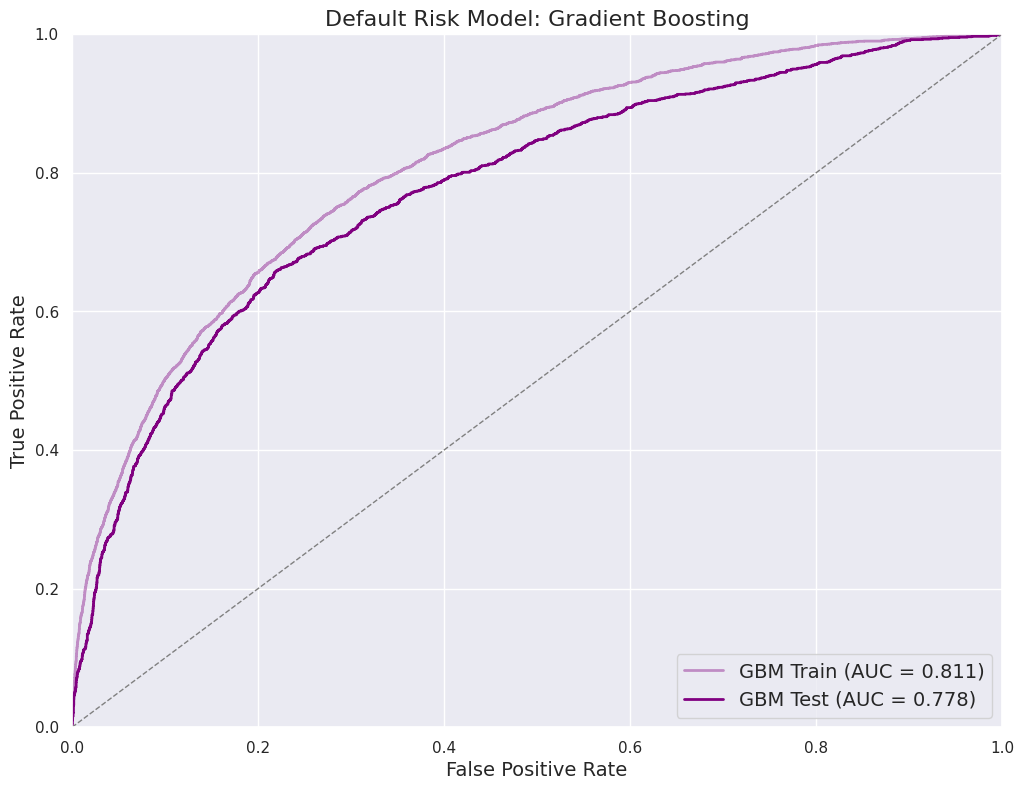

In [23]:
plot_train_test_roc(
    gbm_roc_train,
    gbm_roc_test,
    key='GBM',
    color='purple',
    model_label='GBM',
    title='Default Risk Model: Gradient Boosting'
)

### Final model

The best performance was achieved by the GBM model: AUC = 0.778 on the test set.

Let's refit this model on the Train + Test dataset.

In [24]:
gbm_final = GradientBoostingClassifier(n_estimators = 300, 
                                       min_samples_leaf = 0.01, 
                                       max_depth = 3, 
                                       learning_rate = 0.05,
                                       random_state=314)

X_train_test = X[(X['group'] == 'M') | (X['group'] == 'T')].drop('group', axis=1)
y_train_test = y[(X['group'] == 'M') | (X['group'] == 'T')]

gbm_final.fit(X_train_test, y_train_test)

gbm_scores_valid = gbm_final.predict_proba(X_valid)[:, 1]

gbm_fpr_valid, gbm_tpr_valid, _ = roc_curve(y_valid, gbm_scores_valid)

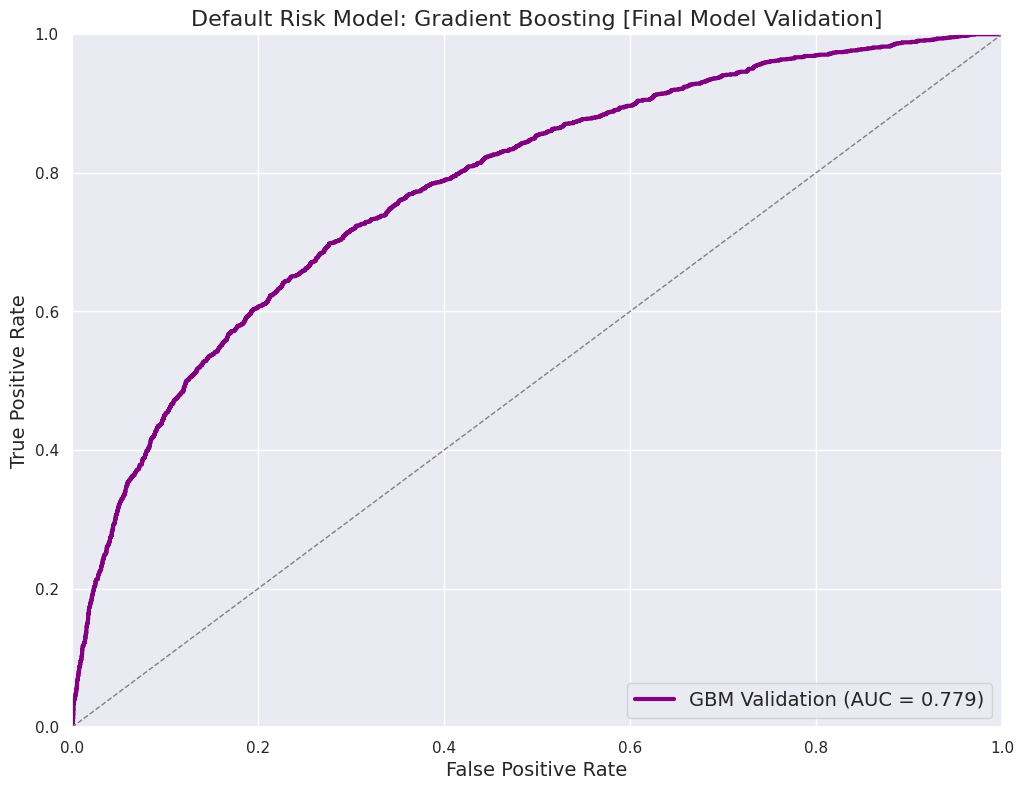

In [25]:
# ROC Curve
plt.figure(figsize=(12, 9))

plt.plot(gbm_fpr_valid, gbm_tpr_valid, color='purple', lw=3,
         label=f'GBM Validation (AUC = {roc_auc_score(y_valid, gbm_scores_valid):0.3f})')

plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.title('Default Risk Model: Gradient Boosting [Final Model Validation]', fontsize=16)
plt.legend(loc='lower right', fontsize=14);

Additionally, we can review the feature importances and reduce the model complexity by discarding irrelevant features.

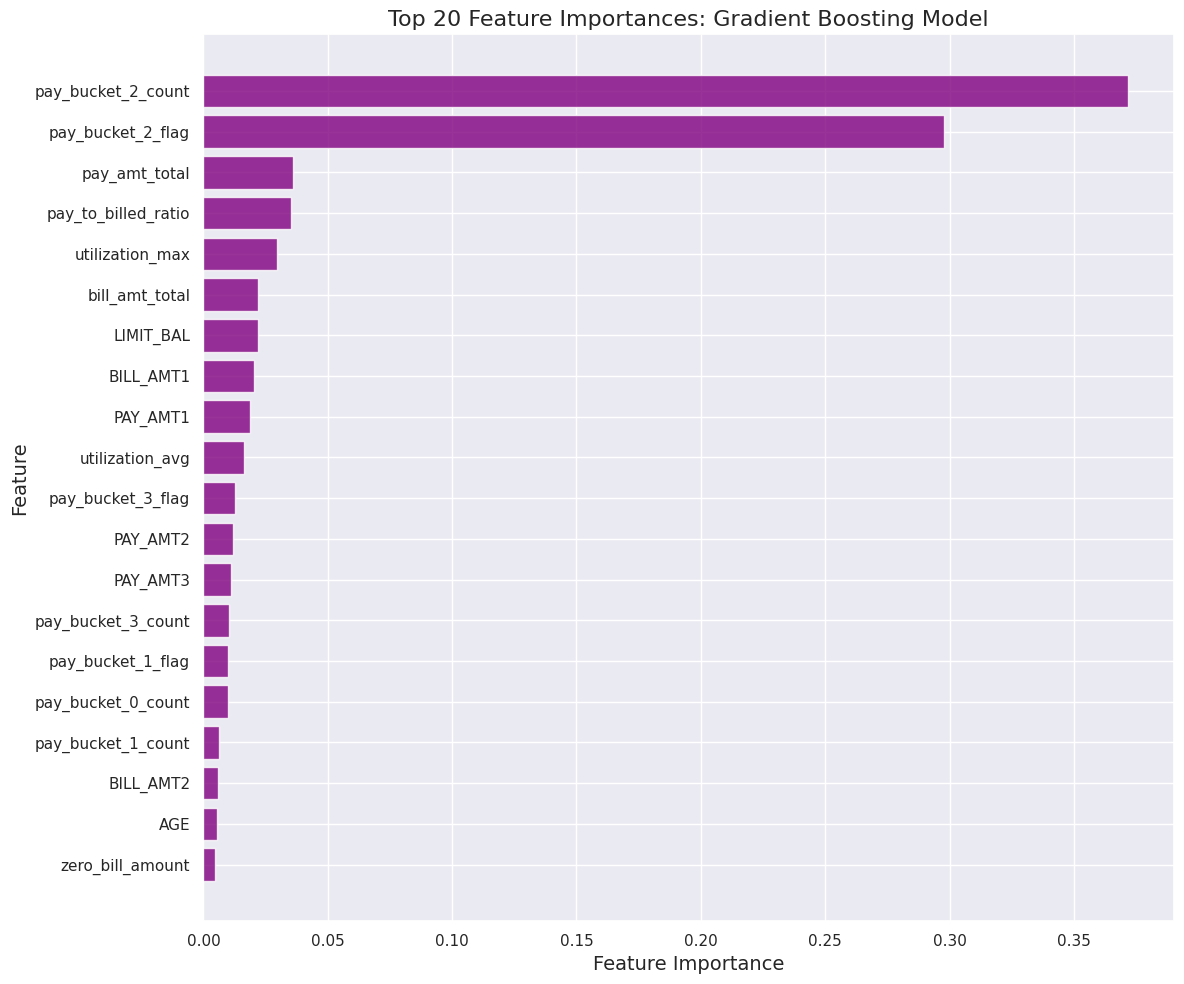

In [26]:
# plot feature importances from the final GBM model
feature_importance = pd.DataFrame({
    'feature': X_train_test.columns,
    'importance': gbm_final.feature_importances_
})

feature_importance = feature_importance.sort_values('importance', ascending=False)

plt.figure(figsize=(12, 10))
plt.barh(feature_importance['feature'][:20], feature_importance['importance'][:20], color='purple', alpha=0.8)
plt.gca().invert_yaxis()
plt.xlabel('Feature Importance', fontsize=14)
plt.ylabel('Feature', fontsize=14)
plt.title('Top 20 Feature Importances: Gradient Boosting Model', fontsize=16)
plt.tight_layout();

### Save the model

In [27]:
from joblib import dump

dump(gbm_final, '../misc/credit_card_default_gbm_model.joblib')

['../misc/credit_card_default_gbm_model.joblib']

### Load the model (to score a dataset in production)

In [28]:
from joblib import load

gbm_prod = load('../misc/credit_card_default_gbm_model.joblib')

scores = gbm_prod.predict_proba(X_valid)
scores[:10]

array([[0.82727355, 0.17272645],
       [0.86091813, 0.13908187],
       [0.74764773, 0.25235227],
       [0.91107297, 0.08892703],
       [0.84780164, 0.15219836],
       [0.8106093 , 0.1893907 ],
       [0.83911306, 0.16088694],
       [0.91611577, 0.08388423],
       [0.61174231, 0.38825769],
       [0.7778737 , 0.2221263 ]])